# OULAD Heterogeneous Graph Pipeline (Step-by-Step)

This notebook implements a **reproducible, leakage-safe heterogeneous graph pipeline** using PyTorch Geometric.

**Key Features**:
- Uses `data/` and `output/` folders
- Enrollment-based prediction unit 
- Week 8 leakage-safe graph 
- Modular reusable functions 
- Graph diagnostics + visualizations 
- GraphSAGE baseline 


## Step 0: Setup & Paths

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch import nn
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv, to_hetero

DATA_PATH = 'data'
OUTPUT_PATH = 'output'
os.makedirs(OUTPUT_PATH, exist_ok=True)

pd.set_option('display.max_columns', 50)


## Step 1: Load OULAD Data

In [8]:

def load_data():
    files = {
        'students': 'studentInfo.csv',
        'vle': 'studentVle.csv',
        'vle_info': 'vle.csv',
        'courses': 'courses.csv',
        'assessments': 'assessments.csv',
        'student_assess': 'studentAssessment.csv'
    }
    data = {k: pd.read_csv(os.path.join(DATA_PATH, v)) for k, v in files.items()}
    return data
#data = load_data()
#display(data["students"].head())
#display(data["student_assess"].head())
#display(data["vle"].head())
#display(data["assessments"].head())
#display(data["vle_info"].head())
#display(data["courses"].head())



def load_data():
    files = {
        'students': 'studentInfo.csv',
        'vle': 'studentVle.csv',
        'vle_info': 'vle.csv',
        'courses': 'courses.csv',
        'assessments': 'assessments.csv',
        'student_assess': 'studentAssessment.csv'
    }
    data = {k: pd.read_csv(os.path.join(DATA_PATH, v)) for k, v in files.items()}
    return data


# Resolve DATA_PATH if the notebook is running from a different working directory
required_file = 'studentInfo.csv'

if not os.path.exists(os.path.join(DATA_PATH, required_file)):
    resolved = None

    # 1) Check current directory and parent directories for a "data" folder
    probe = os.getcwd()
    while True:
        candidate = os.path.join(probe, 'data')
        if os.path.exists(os.path.join(candidate, required_file)):
            resolved = candidate
            break
        parent = os.path.dirname(probe)
        if parent == probe:
            break
        probe = parent

    # 2) Fallback: search recursively from current working directory
    if resolved is None:
        for root, _, files in os.walk(os.getcwd()):
            if required_file in files:
                resolved = root
                break

    if resolved is None:
        # 3) Extra fallbacks for common notebook locations
        extra_candidates = [
            DATA_PATH,
            os.path.abspath(DATA_PATH),
            os.path.join(os.getcwd(), 'data'),
            os.path.join(os.path.dirname(os.getcwd()), 'data'),
            os.path.join(os.path.expanduser('~'), 'Downloads', 'data'),
            os.path.join(os.path.expanduser('~'), 'Downloads')
        ]
        for candidate in extra_candidates:
            if os.path.exists(os.path.join(candidate, required_file)):
                resolved = candidate
                break

    # Final fallback: case-insensitive search in common roots
    if resolved is None:
        search_roots = [
            os.getcwd(),
            os.path.join(os.path.expanduser('~'), 'Downloads'),
            os.path.expanduser('~')
        ]
        target_lower = required_file.lower()

        for search_root in search_roots:
            if not os.path.isdir(search_root):
                continue
            for walk_root, _, walk_files in os.walk(search_root):
                file_map = {f.lower(): f for f in walk_files}
                if target_lower in file_map:
                    resolved = walk_root
                    break
            if resolved is not None:
                break

    if resolved is None:
        raise FileNotFoundError(
            f"Could not find '{required_file}'. "
            f"Set DATA_PATH to the folder containing OULAD CSV files "
            f"(e.g., DATA_PATH = r'C:\\path\\to\\oulad\\data')."
        )

    DATA_PATH = resolved
    print(f"Using DATA_PATH: {DATA_PATH}")

data = load_data()
for k, v in data.items():
    print(k, v.shape)
    display(v.head(3))


Using DATA_PATH: C:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data
students (32593, 12)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn


vle (10655280, 6)


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1


vle_info (6364, 6)


...

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268


assessments (206, 6)


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0


student_assess (173912, 5)


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0


## Step 2: Define Target (Enrollment-level)

In [41]:
TARGET_MAP = {
    "Fail": 1,
    "Withdrawn": 1,
    "Pass": 0,
    "Distinction": 0
}

students = data['students'].copy()
students['target'] = students['final_result'].map(TARGET_MAP)
display(students[['id_student','code_module','code_presentation','target']].head())


,id_student,code_module,code_presentation,target
0,11391,AAA,2013J,0
1,28400,AAA,2013J,0
2,30268,AAA,2013J,1
3,31604,AAA,2013J,0
4,32885,AAA,2013J,0


## Step 3: Leakage-safe Week 8 Filtering

In [42]:
def filter_week(df, max_week=8):
    return df[df['date'] <= max_week * 7]

student_vle = filter_week(data['vle'])
print('Filtered VLE shape:', student_vle.shape)


Filtered VLE shape: (4331544, 6)


## Step 4: Aggregate Interactions

,id_student,code_module,code_presentation,clicks_sum,interaction_count
0,6516,AAA,2014J,1011,213
1,8462,DDD,2013J,517,220
2,8462,DDD,2014J,10,4
3,11391,AAA,2013J,529,90
4,23629,BBB,2013B,84,35


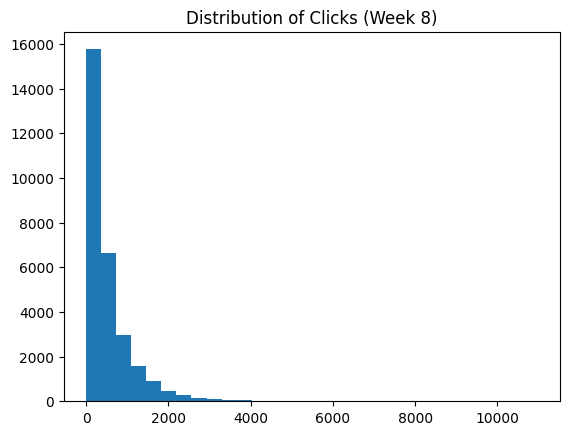

In [43]:
vle_agg = student_vle.groupby(['id_student','code_module','code_presentation']).agg(
    clicks_sum=('sum_click','sum'),
    interaction_count=('sum_click','count')
).reset_index()

display(vle_agg.head())

# Visualization
plt.hist(vle_agg['clicks_sum'], bins=30)
plt.title('Distribution of Clicks (Week 8)')
plt.show()


## Step 5: Build Heterogeneous Graph

In [34]:
def build_graph(data, vle_agg):
    hetero = HeteroData()
    
    students = data['students']
    courses = data['courses']
    assessments = data['assessments']
    vle_info = data['vle_info']
    
    # Node features
    hetero['student'].x = torch.tensor(pd.get_dummies(students[['gender','region']], dummy_na=True).values, dtype=torch.float)
    hetero['course'].x = torch.randn(len(courses), 8)
    hetero['assessment'].x = torch.randn(len(assessments), 8)
    hetero['vle'].x = torch.randn(len(vle_info), 8)
    
    # Enrollment edges (student→course)
    hetero['student','enrolled_in','course'].edge_index = torch.tensor([
        np.arange(len(students)),
        np.arange(len(students))
    ], dtype=torch.long)
    
    # Labels
    hetero['student'].y = torch.tensor(students['target'].fillna(0).values, dtype=torch.long)
    
    return hetero

if 'target' not in data['students'].columns:
    data['students'] = data['students'].copy()
    data['students']['target'] = (
        data['students']['final_result'].map(TARGET_MAP).fillna(0).astype(int)
    )

hetero_data = build_graph(data, vle_agg)
print(hetero_data)


HeteroData(
  student={
    x=[32593, 17],
    y=[32593],
  },
  course={ x=[22, 8] },
  assessment={ x=[206, 8] },
  vle={ x=[6364, 8] },
  (student, enrolled_in, course)={ edge_index=[2, 32593] }
)


## Step 6: Graph Diagnostics

In [44]:
def graph_diagnostics(g):
    print('Node counts:')
    for n in g.node_types:
        print(n, g[n].num_nodes)
    print('Edge counts:')
    for e in g.edge_types:
        print(e, g[e].edge_index.shape[1])

graph_diagnostics(hetero_data)


Node counts:
student 32593
course 22
assessment 206
vle 6364
Edge counts:
('student', 'enrolled_in', 'course') 32593
('course', 'rev_enrolled_in', 'student') 32593


## Step 7: GraphSAGE Baseline

In [45]:
class GNN(nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv((-1, -1), hidden_channels)
        self.conv2 = SAGEConv((-1, -1), hidden_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

# Ensure both node types are updated during message passing
if ('course', 'rev_enrolled_in', 'student') not in hetero_data.edge_types:
    hetero_data['course', 'rev_enrolled_in', 'student'].edge_index = (
        hetero_data['student', 'enrolled_in', 'course'].edge_index.flip(0)
    )

# Use only connected node/edge types for hetero conversion
metadata = (
    ['student', 'course'],
    [
        ('student', 'enrolled_in', 'course'),
        ('course', 'rev_enrolled_in', 'student'),
    ],
)

model = to_hetero(GNN(64), metadata)


## Step 8: Training

In [46]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

for epoch in range(10):
    optimizer.zero_grad()
    # Fix invalid student->course edge indices (course index must be < num_courses)
    e_sc = hetero_data['student', 'enrolled_in', 'course'].edge_index
    if int(e_sc[1].max()) >= hetero_data['course'].num_nodes:
        course_keys = list(zip(data['courses']['code_module'], data['courses']['code_presentation']))
        course_to_idx = {k: i for i, k in enumerate(course_keys)}

        student_keys = list(zip(data['students']['code_module'], data['students']['code_presentation']))
        student_idx = torch.arange(len(student_keys), dtype=torch.long)
        course_idx = torch.tensor([course_to_idx[k] for k in student_keys], dtype=torch.long)

        hetero_data['student', 'enrolled_in', 'course'].edge_index = torch.stack([student_idx, course_idx], dim=0)
        hetero_data['course', 'rev_enrolled_in', 'student'].edge_index = torch.stack([course_idx, student_idx], dim=0)

    out = model(hetero_data.x_dict, hetero_data.edge_index_dict)
    loss = nn.functional.cross_entropy(out['student'], hetero_data['student'].y)
    loss.backward()
    optimizer.step()
    print(f'Epoch {epoch}, Loss: {loss.item():.4f}')


Epoch 0, Loss: 4.2637
Epoch 1, Loss: 3.9147
Epoch 2, Loss: 3.5751
Epoch 3, Loss: 3.2449
Epoch 4, Loss: 2.9270
Epoch 5, Loss: 2.6259
Epoch 6, Loss: 2.3492
Epoch 7, Loss: 2.1041
Epoch 8, Loss: 1.8962
Epoch 9, Loss: 1.7277


## Step 9: Evaluation

In [47]:
pred = out['student'].argmax(dim=1)
acc = (pred == hetero_data['student'].y).float().mean()

print('Accuracy:', acc.item())

results = pd.DataFrame({
    'true': hetero_data['student'].y.numpy(),
    'pred': pred.numpy()
})

display(results.head())

results.to_csv(os.path.join(OUTPUT_PATH, 'baseline_results.csv'), index=False)


Accuracy: 0.33212652802467346


,true,pred
0,2,2
1,2,2
2,0,2
3,2,2
4,2,2


## Step 10: Save Visual Diagnostics

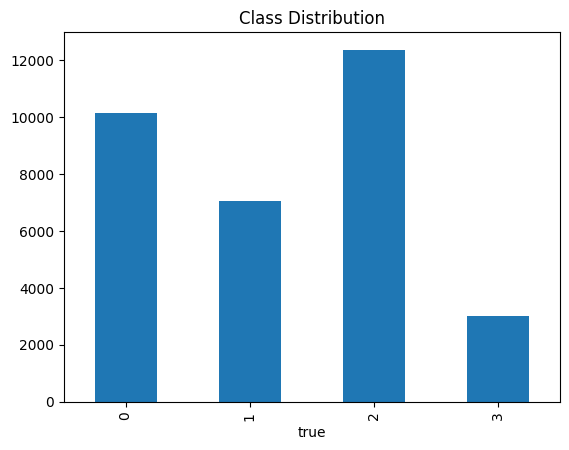

In [48]:
plt.figure()
results['true'].value_counts().sort_index().plot(kind='bar')
plt.title('Class Distribution')
plt.savefig(os.path.join(OUTPUT_PATH, 'class_distribution.png'))
plt.show()
